<a href="https://colab.research.google.com/github/MonishaPandhi/MonishaPandhi---DataScience---GenAI---Submissions/blob/main/Logistic_regression_individual_practice_COMPLETED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons, make_classification # generate synthetic data
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay as CM, f1_score
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression

# Make sure you have run: pip install imbalanced-learn if not using Colab
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Special pipeline for samplers
np.random.seed(100)

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Display the first 20 rows of the DataFrame
print("First 20 rows of the Iris dataset:")
print(iris_df.head(20))

First 20 rows of the Iris dataset:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                 5.1               3.5                1.4               0.2
1                 4.9               3.0                1.4               0.2
2                 4.7               3.2                1.3               0.2
3                 4.6               3.1                1.5               0.2
4                 5.0               3.6                1.4               0.2
5                 5.4               3.9                1.7               0.4
6                 4.6               3.4                1.4               0.3
7                 5.0               3.4                1.5               0.2
8                 4.4               2.9                1.4               0.2
9                 4.9               3.1                1.5               0.1
10                5.4               3.7                1.5               0.2
11                4.8               3.4  

In [ ]:
X = iris_df
y = iris.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 rows of X:\n", X.head())
print("First 5 values of y:\n", y[:5])

Shape of X: (150, 4)
Shape of y: (150,)
First 5 rows of X:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
First 5 values of y:
 [0 0 0 0 0]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on X_train
scaler.fit(X_train)

# Transform both X_train and X_test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames, preserving column names
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("X_train after scaling (first 5 rows):\n", X_train.head())
print("\nX_test after scaling (first 5 rows):\n", X_test.head())

X_train after scaling (first 5 rows):
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
22           0.088235          0.666667           0.000000          0.041667
15           0.411765          1.000000           0.087719          0.125000
65           0.705882          0.458333           0.596491          0.541667
11           0.147059          0.583333           0.105263          0.041667
42           0.029412          0.500000           0.052632          0.041667

X_test after scaling (first 5 rows):
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
73            0.529412          0.333333           0.649123          0.458333
18            0.411765          0.750000           0.122807          0.083333
118           1.000000          0.250000           1.035088          0.916667
78            0.500000          0.375000           0.614035          0.583333
76            0.735294          0.333333           0.666667          0

I generated a train-test split for my data to help build my model. I have checked that the test data is only 20% and we have 4 features. I also scaled the training data to minimise bias.

AI prompts used: Generate a train test split for the iris data where only 20% will be test data. Use a minmax scaler for the train data.


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.90      0.88      0.89        41
           2       0.88      0.90      0.89        39

    accuracy                           0.93       120
   macro avg       0.92      0.93      0.92       120
weighted avg       0.93      0.93      0.93       120



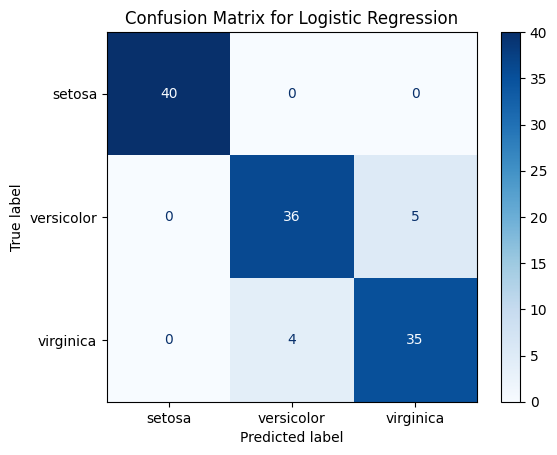

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

# Make predictions on the train data
y_pred = log_reg_model.predict(X_train)

# Calculate and print precision, F1, and recall scores
print("\nClassification Report:\n", classification_report(y_train, y_pred))

# Display the confusion matrix
cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

As the iris dataset is primarily dealing with categories, I have used a logistic regression model. I then examined the precision, recall and f1 scores for the model to assess its accuracy. This model is 93% accurate on the trained data. As seen by the confusion matrix, the false positives and false negatives are distributed evenly across setosa, versicolour and virginica displaying that this model has minimal bias which is essential when dealing with biological data.

AI prompt used: Generate a logistic regression model for the train data. Calculate the precision, f1 and recall scores. Also show a confusion matrix for the data.

In [ ]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

print("Defined hyperparameter grid:")
print(param_grid)

Defined hyperparameter grid:
{'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}


In [ ]:
from sklearn.model_selection import GridSearchCV

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=LogisticRegression(max_iter=1000, random_state=42), # Use the same max_iter and random_state as before
                           param_grid=param_grid,
                           cv=5, # 5-fold cross-validation
                           scoring='accuracy', # Evaluate based on accuracy
                           n_jobs=-1, # Use all available CPU cores
                           verbose=1) # Print progress

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Best hyperparameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best hyperparameters found: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation accuracy: 0.95



Classification Report for Tuned Logistic Regression Model:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.91      0.95      0.93        41
           2       0.95      0.90      0.92        39

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120



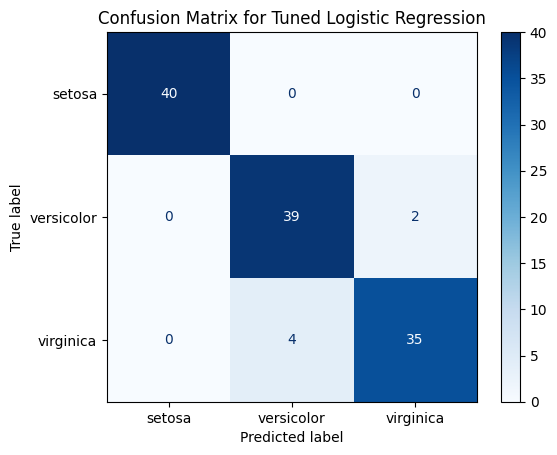

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train the Logistic Regression model with the best hyperparameters
best_log_reg_model = LogisticRegression(max_iter=1000, random_state=42, **grid_search.best_params_)
best_log_reg_model.fit(X_train, y_train)

# Make predictions on the train data
y_pred_tuned = best_log_reg_model.predict(X_train)

# Calculate and print precision, F1, and recall scores for the tuned model
print("\nClassification Report for Tuned Logistic Regression Model:\n", classification_report(y_train, y_pred_tuned))

# Display the confusion matrix for the tuned model
cm_tuned = confusion_matrix(y_train, y_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=iris.target_names)
disp_tuned.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned Logistic Regression')
plt.show()

I decided to place hyperparameters on the logistic regression model to see whether the accuracy will improve. After assessing the confusion matrix, precision, recall and f1 scores, the model is shown to be 95% accurate on the train data.

AI prompt used: Use hyperparameters on the logistic regression model using the train data to improve accuracy.


Classification Report for Decision Tree Model (Train Data):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        41
           2       1.00      1.00      1.00        39

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



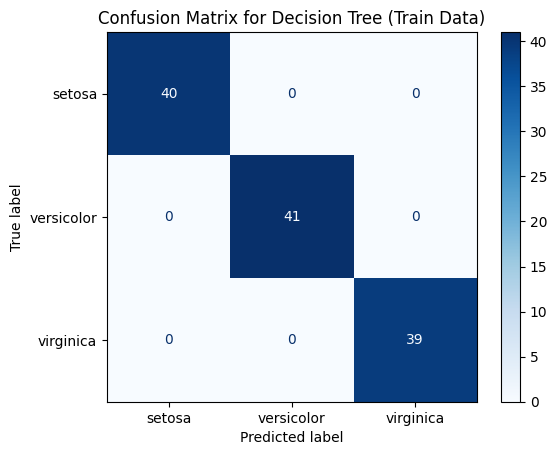

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize and train the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions on the train data
y_pred_dt = decision_tree_model.predict(X_train)

# Calculate and print accuracy scores
print("\nClassification Report for Decision Tree Model (Train Data):\n", classification_report(y_train, y_pred_dt))

# Display the confusion matrix
cm_dt = confusion_matrix(y_train, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=iris.target_names)
disp_dt.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Decision Tree (Train Data)')
plt.show()

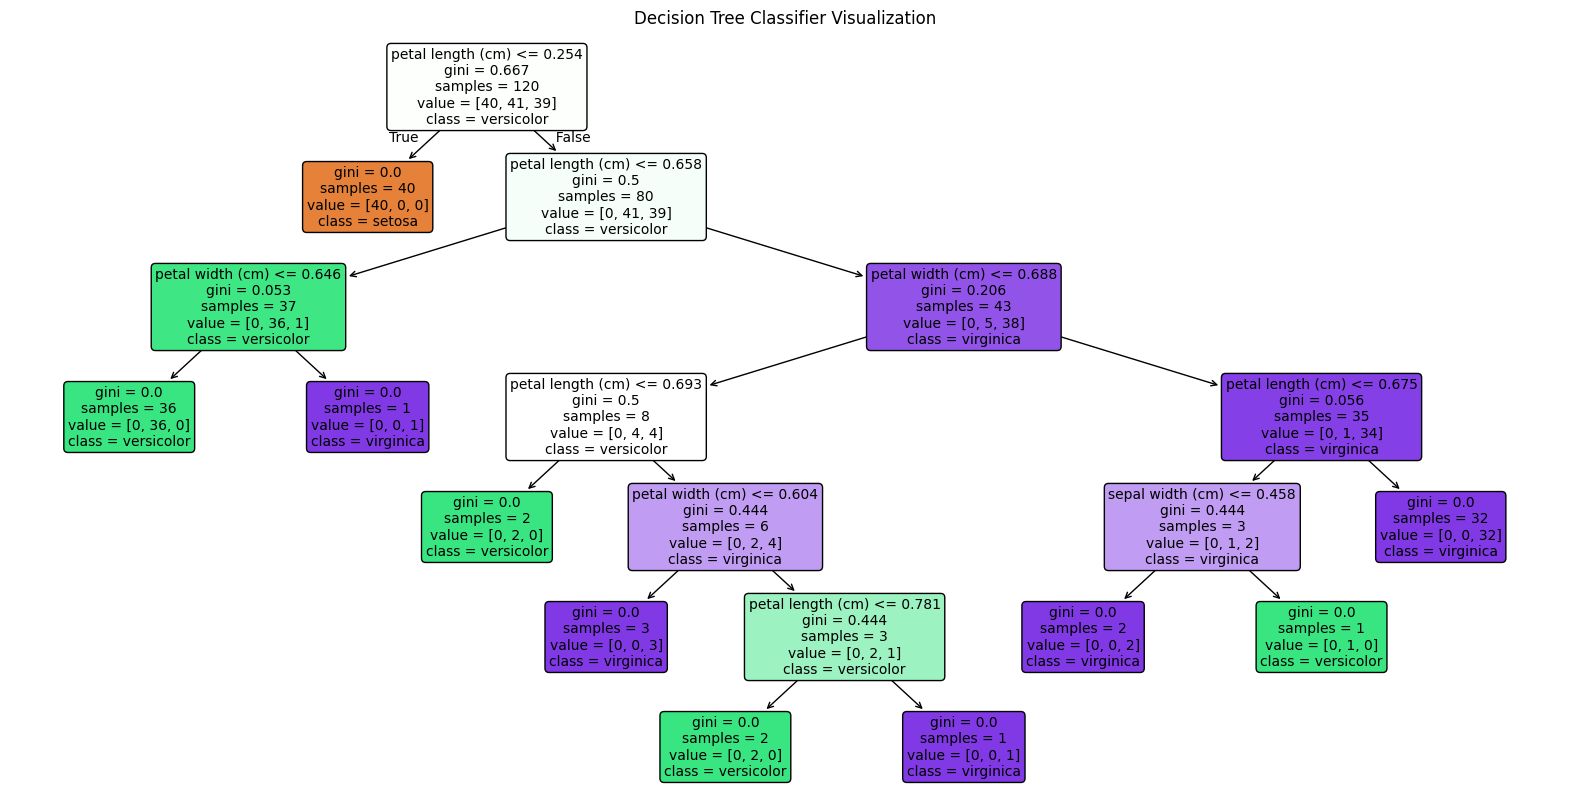

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
plot_tree(decision_tree_model,
          feature_names=X.columns,  # Use original feature names
          class_names=iris.target_names, # Use original class names
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Classifier Visualization')
plt.show()

I have run a decision tree classifier model in attempts to improve accuracy. Upon assessing the different accuracy scores, the model is fully accurate on the train data. The confusion matrix also shows this as there are no false positives or false negatives. I then plotted it visually as a decision tree and it's clear that the model is neither been overfit or underfit.

AI Prompts used:
- generate a decision tree classifier model on the train data. calculate the relevant accuracy scores and do a confusion matrix
- Plot the decision tree


Classification Report for Decision Tree Model (Test Data):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



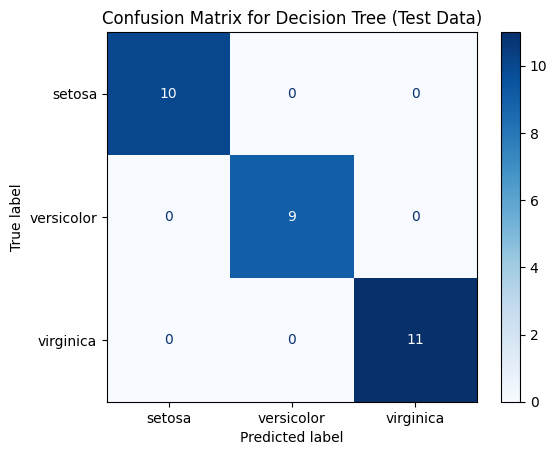

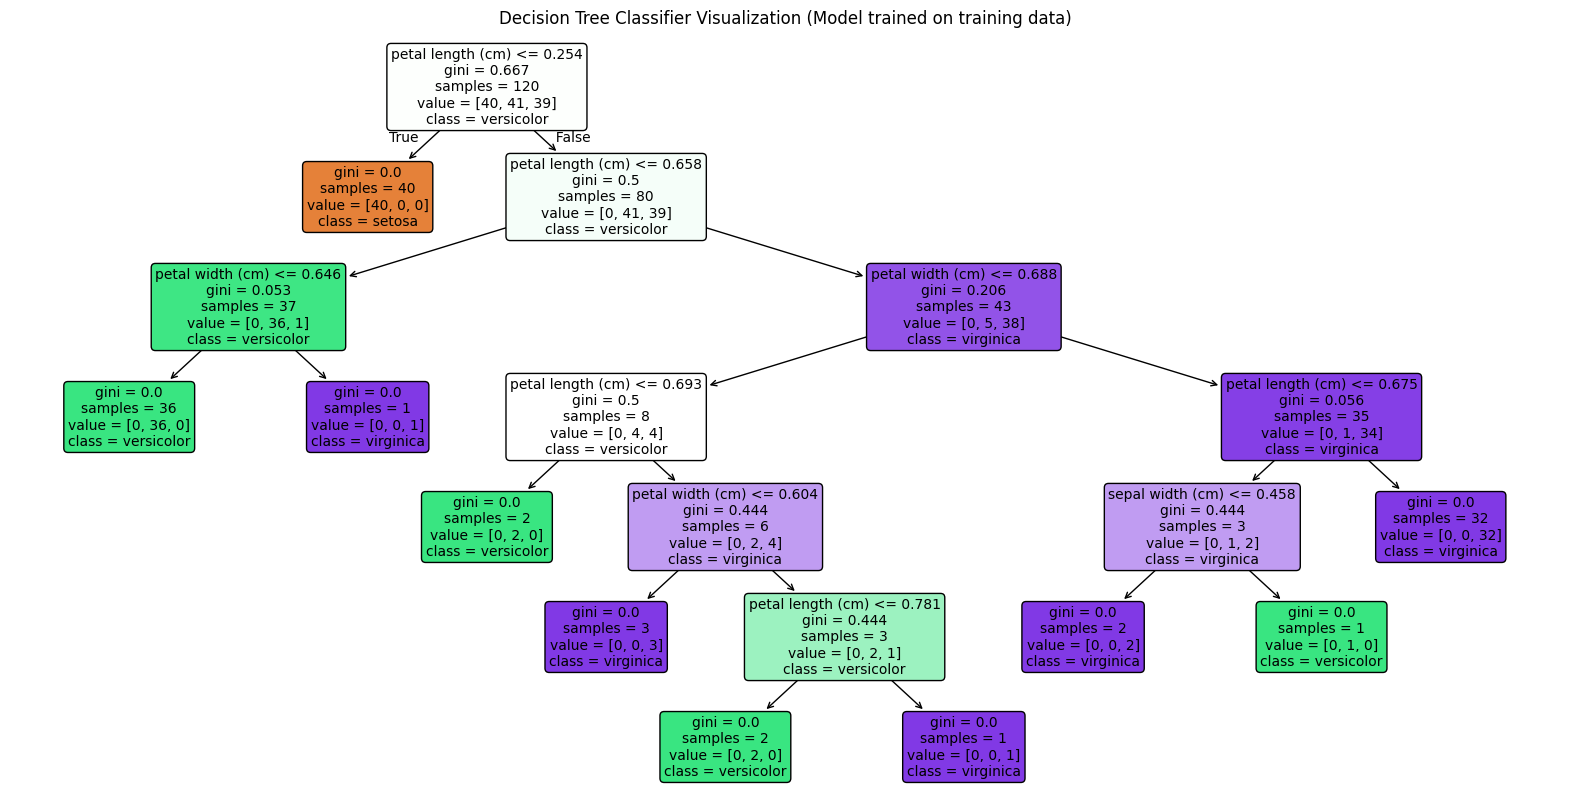

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test data
y_pred_dt_test = decision_tree_model.predict(X_test)

# Calculate and print accuracy scores for test data
print("\nClassification Report for Decision Tree Model (Test Data):\n", classification_report(y_test, y_pred_dt_test))

# Display the confusion matrix for test data
cm_dt_test = confusion_matrix(y_test, y_pred_dt_test)
disp_dt_test = ConfusionMatrixDisplay(confusion_matrix=cm_dt_test, display_labels=iris.target_names)
disp_dt_test.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Decision Tree (Test Data)')
plt.show()

# Plot the decision tree (the structure learned from training data)
plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
plot_tree(decision_tree_model,
          feature_names=X.columns,  # Use original feature names
          class_names=iris.target_names, # Use original class names
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Classifier Visualization (Model trained on training data)')
plt.show()

Upon running the decision tree classifier model on the test data, it is clear that this model displays that the features (sepal length/width, petal length/width) provide enough information to differentiate between the species with high precision hence are easily classifiable. The decision tree is ideally fitted (no overfitting or underfitting). However, this is a small dataset so it's easier achieving 100% accuracy with the model.

AI prompt used: run the decision tree classifier model on the test data. calculate the relevant accuracy scores, present the information in a confusion matrix and plot a decision tree